<a href="https://colab.research.google.com/github/dibyaswayam2005/pneumonia-xray-classifier/blob/main/pneumonia_xray_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import os

# ⚠️ IMPORTANT: Delete this token string before saving a copy to GitHub!
os.environ['KAGGLE_API_TOKEN'] = "API Token"

# Install the Kaggle library
!pip install -q kaggle

# Download the Chest X-Ray dataset!
print("Downloading dataset...")
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

# Unzip the downloaded file silently into a folder named 'dataset'
print("Unzipping files...")
!unzip -q chest-xray-pneumonia.zip -d dataset/
print("Dataset successfully downloaded and unzipped! 🎉")

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:23<00:00, 106MB/s] 

Unzipping files...
Dataset successfully downloaded and unzipped! 🎉


📊 Dataset Breakdown:
-------------------------
TRAIN - NORMAL: 1341 images
TRAIN - PNEUMONIA: 3875 images
TEST - NORMAL: 234 images
TEST - PNEUMONIA: 390 images
VAL - NORMAL: 8 images
VAL - PNEUMONIA: 8 images

🖼️ Loading Sample Images...


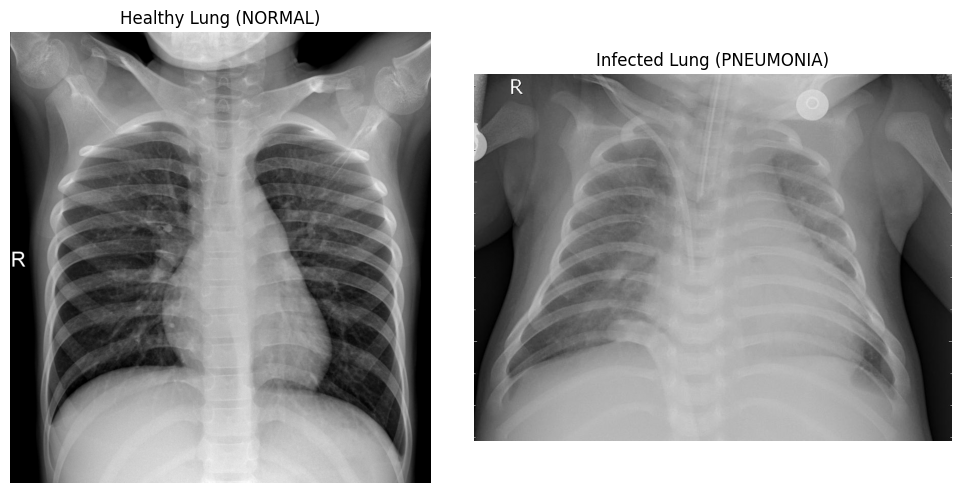

In [2]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import glob

# The Kaggle zip usually creates a nested folder structure
base_path = 'dataset/chest_xray'

print("📊 Dataset Breakdown:")
print("-" * 25)
# Count the images in each folder
for split in ['train', 'test', 'val']:
    for condition in ['NORMAL', 'PNEUMONIA']:
        folder_path = os.path.join(base_path, split, condition)
        # Count all .jpeg files in the folder
        image_count = len(glob.glob(os.path.join(folder_path, '*.jpeg')))
        print(f"{split.upper()} - {condition}: {image_count} images")

print("\n🖼️ Loading Sample Images...")

# Grab one normal and one pneumonia image from the training set
normal_img_path = glob.glob(os.path.join(base_path, 'train', 'NORMAL', '*.jpeg'))[0]
pneumonia_img_path = glob.glob(os.path.join(base_path, 'train', 'PNEUMONIA', '*.jpeg'))[0]

# Plot the images side-by-side
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(mpimg.imread(normal_img_path), cmap='gray')
axes[0].set_title("Healthy Lung (NORMAL)")
axes[0].axis('off')

axes[1].imshow(mpimg.imread(pneumonia_img_path), cmap='gray')
axes[1].set_title("Infected Lung (PNEUMONIA)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [5]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 1. Define the transformations for the training images (includes augmentation)
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(10),       # Randomly rotate by +/- 10 degrees
    transforms.RandomHorizontalFlip(),   # Randomly flip horizontally
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Test and Val images should NOT be rotated or flipped; they must remain pure for grading
test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 2. Load the datasets from our unzipped folders
train_dataset = datasets.ImageFolder(root='dataset/chest_xray/train', transform=train_transforms)
val_dataset = datasets.ImageFolder(root='dataset/chest_xray/val', transform=test_transforms)
test_dataset = datasets.ImageFolder(root='dataset/chest_xray/test', transform=test_transforms)

# 3. Create DataLoaders (this batches the images together so the GPU doesn't crash)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Successfully loaded {len(train_dataset)} training images into batches! 🚀")

Successfully loaded 5216 training images into batches! 🚀


In [6]:
import torch
import torch.nn as nn
from torchvision import models

# 1. Check if the free GPU is active
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Hardware computing device: {device}")

# 2. Download the pre-trained ResNet18 model
# (weights='DEFAULT' downloads the best, most up-to-date learned patterns)
model = models.resnet18(weights='DEFAULT')

# 3. Modify the final layer for our specific problem
# ResNet originally outputs 1000 classes. We only want 2 (Normal vs. Pneumonia)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)

# 4. Move the massive model onto our GPU for lightning-fast training
model = model.to(device)

print("Brain successfully transplanted and ready for training! 🧠")

Hardware computing device: cuda
Brain successfully transplanted and ready for training! 🧠


In [7]:
import torch.optim as optim
import time

# 1. Define the Grader (Loss) and the Updater (Optimizer)
criterion = torch.nn.CrossEntropyLoss()
# lr=0.001 is the "learning rate" - how big of a step it takes when fixing mistakes
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 3

print("Starting the training sequence... Grab a coffee! ☕\n")
start_time = time.time()

# 2. The Training Loop
for epoch in range(epochs):
    model.train() # Put the model into training mode
    running_loss = 0.0

    # Loop through the data in batches of 32
    for i, (images, labels) in enumerate(train_loader):
        # Move images and labels to the GPU
        images, labels = images.to(device), labels.to(device)

        # Step A: Clear out old memory
        optimizer.zero_grad()

        # Step B: Forward Pass (The AI makes a guess)
        outputs = model(images)

        # Step C: Calculate the mistake
        loss = criterion(outputs, labels)

        # Step D: Backward Pass (Calculate how to fix the mistake)
        loss.backward()

        # Step E: Take a step and actually update the brain
        optimizer.step()

        running_loss += loss.item()

    # 3. Validation Phase (Check how it does on the practice quiz)
    model.eval() # Put the model into testing mode (turns off random augmentations)
    correct = 0
    total = 0

    # We use torch.no_grad() because we aren't learning here, just testing, which saves memory
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            # Find the highest probability guess
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_accuracy = 100 * correct / total
    avg_loss = running_loss / len(train_loader)

    print(f"Epoch [{epoch+1}/{epochs}] | Training Loss: {avg_loss:.4f} | Validation Accuracy: {val_accuracy:.2f}%")

end_time = time.time()
print(f"\nTraining complete in {(end_time - start_time)/60:.1f} minutes! 🎉")

Starting the training sequence... Grab a coffee! ☕

Epoch [1/3] | Training Loss: 0.1515 | Validation Accuracy: 93.75%
Epoch [2/3] | Training Loss: 0.0839 | Validation Accuracy: 50.00%
Epoch [3/3] | Training Loss: 0.0707 | Validation Accuracy: 62.50%

Training complete in 5.1 minutes! 🎉


In [8]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

model.eval()  # Set model to evaluation mode
all_preds = []
all_labels = []

print("Running the final exam on the Test Set... 📝")

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Calculate metrics
cm = confusion_matrix(all_labels, all_preds)
print("\n📊 FINAL TEST RESULTS:")
print("-" * 30)
print(classification_report(all_labels, all_preds, target_names=['NORMAL', 'PNEUMONIA']))

# Plot the Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['NORMAL', 'PNEUMONIA'], yticklabels=['NORMAL', 'PNEUMONIA'])
plt.title('Final Test Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

Running the final exam on the Test Set... 📝

📊 FINAL TEST RESULTS:
------------------------------
              precision    recall  f1-score   support

      NORMAL       0.99      0.41      0.58       234
   PNEUMONIA       0.74      1.00      0.85       390

    accuracy                           0.78       624
   macro avg       0.86      0.70      0.71       624
weighted avg       0.83      0.78      0.75       624



NameError: name 'plt' is not defined

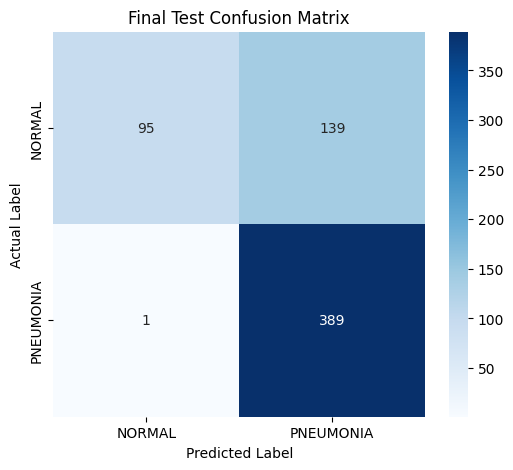

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['NORMAL', 'PNEUMONIA'], yticklabels=['NORMAL', 'PNEUMONIA'])
plt.title('Final Test Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [10]:
import torch.optim as optim
import time

# 1. Calculate Class Weights based on our dataset breakdown
# We give the rarer class (Normal) a higher weight value
weight_for_normal = 3875.0 / 1341.0  # Roughly 2.89
weight_for_pneumonia = 1.0

# Convert weights into a PyTorch Tensor and move to GPU
class_weights = torch.FloatTensor([weight_for_normal, weight_for_pneumonia]).to(device)

# 2. Pass the weights directly into our Loss Function!
criterion = torch.nn.CrossEntropyLoss(weight=class_weights)

# Re-initialize a fresh ResNet18 model so we start clean
from torchvision import models
import torch.nn as nn
model = models.resnet18(weights='DEFAULT')
model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(device)

# Set up the optimizer
optimizer = optim.Adam(model.parameters(), lr=0.0005) # Slower learning rate for fine-tuning
epochs = 2

print("Starting Weighted Training Sequence... ⚖️\n")

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels) # Now applying weighted penalties!
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}] | Weighted Training Loss: {running_loss/len(train_loader):.4f}")

print("\nWeighted training complete! 🎉")

Starting Weighted Training Sequence... ⚖️

Epoch [1/2] | Weighted Training Loss: 0.1357
Epoch [2/2] | Weighted Training Loss: 0.0752

Weighted training complete! 🎉


Running the final exam on the Weighted Model... 📝

📊 NEW WEIGHTED TEST RESULTS:
------------------------------
              precision    recall  f1-score   support

      NORMAL       0.97      0.69      0.81       234
   PNEUMONIA       0.84      0.99      0.91       390

    accuracy                           0.88       624
   macro avg       0.91      0.84      0.86       624
weighted avg       0.89      0.88      0.87       624



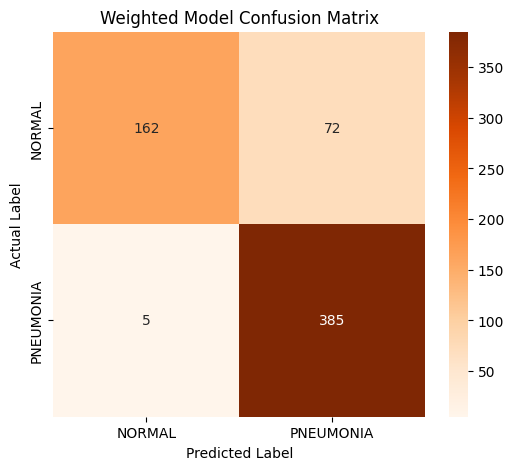

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

model.eval()  # Put model into evaluation mode
all_preds = []
all_labels = []

print("Running the final exam on the Weighted Model... 📝")

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Calculate metrics
cm_weighted = confusion_matrix(all_labels, all_preds)
print("\n📊 NEW WEIGHTED TEST RESULTS:")
print("-" * 30)
print(classification_report(all_labels, all_preds, target_names=['NORMAL', 'PNEUMONIA']))

# Plot the New Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_weighted, annot=True, fmt='d', cmap='Oranges', xticklabels=['NORMAL', 'PNEUMONIA'], yticklabels=['NORMAL', 'PNEUMONIA'])
plt.title('Weighted Model Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()